In [1]:
atomstring = '''
Fe -0.64147387529051 0.51990405379180 0.11450483185168
O 0.33915564253394 2.18819453520299 -0.84159903476570
H 0.65823736209818 2.99799985286513 -0.40575899522591
O -1.29914529040912 -0.20924466129350 -1.80322550106302
H -2.11419692217693 0.03267722517314 -2.27701147100162
O 0.01237770373627 1.24396717111997 2.03533113813669
H 0.83097217272839 1.00756306178418 2.50577204385612
O -1.62284672685044 -1.15048542622041 1.07007991103536
H -1.94592790838151 -1.95766677806096 0.63237073377438
O -2.41866907277644 1.66373032346654 0.25658821238371
H -2.55381601393967 2.56024091790599 -0.09930153080408
O 1.13404022498401 -0.62623224778001 -0.02436092147139
H 1.26370551457750 -1.52400168391753 0.33034524187694
H -3.28110369794222 1.35873477131317 0.59094893393907
H -0.81032015579443 -0.82248643308581 -2.37966496653734
H 1.99795010138314 -0.32692539271158 -0.36001715946551
H 0.57998322602479 2.26642229799559 -1.78148703231078
H -0.47668197075682 1.85673194452426 2.61208351578631
H -1.85653031374812 -1.23356353207299 2.011352050005
'''

In [2]:
import numpy as np
from pyscf import gto, scf, mp, cc

mol = gto.M(atom = atomstring,
            basis = {
                'default': 'ccpvdz-dk',
                'Fe': 'ccpwcvtz-dk'
                },
            verbose = 4,
            unit = 'angstrom',
            symmetry = 0,
            charge = 2,
            spin = 4,
            max_memory = 20000,
            )

mf = scf.UHF(mol).density_fit()
mf = mf.x2c()
dm0 = mf.from_chk('./hs_tdz_mf.chk')
# mf.init_guess = 'chk'
mf.max_cycle = 100
mf.level_shift = 0.5
mf = mf.newton()
mf.kernel(dm0=dm0)

stable = False
for i in range(10):
    print(f'mf stability test {i+1}')
    if not stable:
        mo_i, _, stable,_ = mf.stability(return_status=True)
        dm = mf.make_rdm1(mo_i,mf.mo_occ)
        mf = mf.newton()
        mf.kernel(dm0=dm)
    elif stable:
        print(f'mf energy: {mf.e_tot}, stability {stable}')
        break

System: uname_result(system='Linux', node='sharmagroup-rn', release='7.0.0-28-generic', version='#28~24.04.1-Ubuntu SMP PREEMPT_DYNAMIC Wed Jul  1 15:50:57 UTC 2', machine='x86_64')  Threads 16
Python 3.12.13 | packaged by Anaconda, Inc. | (main, Mar 19 2026, 20:20:58) [GCC 14.3.0]
numpy 2.4.4  scipy 1.17.1  h5py 3.16.0
Date: Sat Aug 15 13:39:20 2026
PySCF version 2.12.1
PySCF path  /home/sharmagroup/sharmagroup/pyscf
GIT ORIG_HEAD 3d1768f5e33b144b606c3d2c81c12ee54d794501
GIT HEAD (branch master) f0861da51f017364d8bbaa20b742a94f3733305f

[ENV] OLD_PYSCF_EXT_PATH /home/sharmagroup/sharmagroup/pyscf-forge:
[ENV] PYSCF_EXT_PATH /home/sharmagroup/sharmagroup/pyscf-forge:/home/sharmagroup/sharmagroup/pyscf-forge:
[CONFIG] conf_file None
[INPUT] verbose = 4
[INPUT] num. atoms = 19
[INPUT] num. electrons = 84
[INPUT] charge = 2
[INPUT] spin (= nelec alpha-beta = 2S) = 4
[INPUT] symmetry 0 subgroup None
[INPUT] Mole.unit = angstrom
[INPUT] Symbol           X                Y                Z  

In [ ]:
# mymp = mp.MP2(mf).set_frozen()
# mymp.kernel()

# mycc = cc.CCSD(mf).set_frozen()
# mycc.conv_tol = 1e-6
# mycc.conv_tol_normt = 3e-5
# mycc.kernel()


******** <class 'pyscf.mp.dfump2.DFUMP2'> ********
nocc = (np.int64(33), np.int64(29)), nmo = (151, 151)
frozen orbitals 11
max_memory 20000 MB (current use 4662 MB)
E(DFUMP2) = -1722.47526863514  E_corr = -1.29286375664304
E(SCS-DFUMP2) = -1722.42428807964  E_corr = -1.24188320114358
E_corr(same-spin) = -0.357176892493924
E_corr(oppo-spin) = -0.935686864149114

******** <class 'pyscf.cc.dfuccsd.UCCSD'> ********
CC2 = 0
CCSD nocc = (np.int64(33), np.int64(29)), nmo = (151, 151)
frozen orbitals 11
max_cycle = 50
direct = 0
conv_tol = 1e-06
conv_tol_normt = 3e-05
diis_space = 6
diis_start_cycle = 0
diis_start_energy_diff = 1e+09
max_memory 20000 MB (current use 5001 MB)
Init t2, MP2 energy = -1.29286375664304
Init E_corr(UCCSD) = -1.2928637566524
cycle = 1  E_corr(UCCSD) = -1.31468018793971  dE = -0.0218164313  norm(t1,t2) = 0.098455
cycle = 2  E_corr(UCCSD) = -1.33811641532451  dE = -0.0234362274  norm(t1,t2) = 0.0275557
cycle = 3  E_corr(UCCSD) = -1.34263910880835  dE = -0.00452269348

(np.float64(-1.3451504149983338),
 (array([[-5.44580226e-04,  1.37727321e-08,  1.46529894e-06, ...,
          -3.40140260e-08,  5.20444589e-08,  8.62234273e-09],
         [ 1.67023816e-07, -7.18423002e-04,  7.93453421e-06, ...,
           9.77803965e-07,  1.20302729e-06, -5.44232383e-05],
         [-5.48727407e-07, -1.18761270e-05,  7.54072342e-04, ...,
          -4.40890672e-05, -4.19740264e-07, -1.57570597e-06],
         ...,
         [ 6.31797591e-05,  6.31216474e-03, -9.85269801e-03, ...,
           3.22058219e-05, -3.55873327e-06,  2.05517127e-05],
         [-6.06917995e-06,  8.81951423e-03,  6.72368705e-03, ...,
          -3.37788369e-05, -8.98732893e-07,  2.85488579e-05],
         [-4.18922086e-04, -1.16182959e-04,  6.06473112e-05, ...,
          -8.79560494e-07,  1.58964137e-05,  1.47704173e-07]],
        shape=(33, 118)),
  array([[ 1.65906600e-07,  3.11391607e-07, -9.28402397e-08, ...,
          -2.87280746e-08, -1.86907867e-09,  7.11708264e-09],
         [-3.60178473e-04, -2

In [174]:
from pyscf.data import elements
import lno_tools
from pyscf.lno import lnoccsd, ulnoccsd, tools
from pyscf.lno.tools import autofrag_iao

iao_coeff, iao_frag_list, atm_center = lno_tools.iao_localization(mf)

In [5]:
nfrozen = elements.chemcore(mol)
nocca = np.count_nonzero(mf.mo_occ[0])
noccb = np.count_nonzero(mf.mo_occ[1])
s1e = mf.get_ovlp()
mo_occa = mf.mo_coeff[0][:,nfrozen:nocca]
mo_occb = mf.mo_coeff[1][:,nfrozen:noccb]
print(lno_tools.mo_span(iao_coeff[0], s1e, mo_occa)) # output 1 = <mo|mo> - <mo|iao><iao|mo>
print(lno_tools.mo_span(iao_coeff[1], s1e, mo_occb)) # output 2 = <iao|iao> - <iao|mo><mo|iao>
print(lno_tools.check_span(mf, iao_coeff, nfrozen)) # for LNO to work, LOs has to span occ MOs

(np.float64(1.4529517812476033e-13), np.float64(0.9999936349065398))
(np.float64(1.4548705325862464e-13), np.float64(0.9999950034866476))
LO occ span the occupied MO occ space - True.
MO occ span the occupied LO occ space - False.
None


In [ ]:
from pyscf import lo
lo_coeff_a = lo.Boys(mol).kernel(iao_coeff[0], verbose=4)
lo_coeff_b = lo.Boys(mol).kernel(iao_coeff[1], verbose=4)
lo_coeff_a = lo.orth.vec_lowdin(lo_coeff_a, mf.get_ovlp())
lo_coeff_b = lo.orth.vec_lowdin(lo_coeff_b, mf.get_ovlp())



******** <class 'pyscf.lo.boys.Boys'> ********
conv_tol = 1e-06
conv_tol_grad = None
max_cycle = 100
max_stepsize = 0.05
max_iters = 20
kf_interval = 5
kf_trust_region = 5
ah_start_tol = 1000000000.0
ah_start_cycle = 1
ah_level_shift = 0
ah_conv_tol = 1e-12
ah_lindep = 1e-14
ah_max_cycle = 40
ah_trust_region = 3
init_guess = atomic
Set conv_tol_grad to 0.000316228
macro= 1  f(x)= 90.922898189725  delta_f= 90.9229  |g|= 3.81288  4 KF 20 Hx
macro= 2  f(x)= 89.429565280611  delta_f= -1.49333  |g|= 1.22815  4 KF 20 Hx
macro= 3  f(x)= 88.536898287844  delta_f= -0.892667  |g|= 0.621467  4 KF 20 Hx
macro= 4  f(x)= 87.907809941129  delta_f= -0.629088  |g|= 0.617405  4 KF 20 Hx
macro= 5  f(x)= 87.263336605395  delta_f= -0.644473  |g|= 0.708114  4 KF 20 Hx
macro= 6  f(x)= 86.971047533332  delta_f= -0.292289  |g|= 0.700216  3 KF 20 Hx
macro= 7  f(x)= 86.677754670011  delta_f= -0.293293  |g|= 0.375994  4 KF 21 Hx
macro= 8  f(x)= 86.465149065804  delta_f= -0.212606  |g|= 0.181946  4 KF 23 Hx
macr

In [226]:
pmiao_coeff_a = lo.PM(mol).kernel(iao_coeff[0], verbose=4)
pmiao_coeff_b = lo.PM(mol).kernel(iao_coeff[1], verbose=4)
pmiao_coeff_a = lo.orth.vec_lowdin(lo_coeff_a, mf.get_ovlp())
pmiao_coeff_b = lo.orth.vec_lowdin(lo_coeff_b, mf.get_ovlp())



******** <class 'pyscf.lo.pipek.PipekMezey'> ********
conv_tol = 1e-06
conv_tol_grad = None
max_cycle = 100
max_stepsize = 0.05
max_iters = 20
kf_interval = 5
kf_trust_region = 5
ah_start_tol = 1000000000.0
ah_start_cycle = 1
ah_level_shift = 0
ah_conv_tol = 1e-12
ah_lindep = 1e-14
ah_max_cycle = 40
ah_trust_region = 3
init_guess = atomic
pop_method = meta_lowdin
Set conv_tol_grad to 0.000316228
macro= 1  f(x)= 56.591473729755  delta_f= 56.5915  |g|= 0.0184944  4 KF 17 Hx
macro= 2  f(x)= 56.59295979033  delta_f= 0.00148606  |g|= 0.0120799  5 KF 28 Hx
macro= 3  f(x)= 56.592987761742  delta_f= 2.79714e-05  |g|= 0.00111887  6 KF 33 Hx
macro= 4  f(x)= 56.592988504715  delta_f= 7.42973e-07  |g|= 0.000316161  6 KF 36 Hx
macro X = 4  f(x)= 56.592988504715  |g|= 0.000316161  8 intor 21 KF 114 Hx


******** <class 'pyscf.lo.pipek.PipekMezey'> ********
conv_tol = 1e-06
conv_tol_grad = None
max_cycle = 100
max_stepsize = 0.05
max_iters = 20
kf_interval = 5
kf_trust_region = 5
ah_start_tol = 100

In [227]:
print(lno_tools.mo_span(pmiao_coeff_a, s1e, mo_occa)) # output 1 = <mo|mo> - <mo|iao><iao|mo>
print(lno_tools.mo_span(pmiao_coeff_b, s1e, mo_occb)) # output 2 = <iao|iao> - <iao|mo><mo|iao>
print(lno_tools.check_span(mf, (pmiao_coeff_a, pmiao_coeff_b), nfrozen)) # for LNO to work, LOs has to span occ MOs

(np.float64(6.039613253960852e-14), np.float64(0.9988936455199021))
(np.float64(7.273885947777295e-14), np.float64(0.9989636347672107))
LO occ span the occupied MO occ space - True.
MO occ span the occupied LO occ space - False.
None


In [228]:
pmiao_coeff = [pmiao_coeff_a, pmiao_coeff_b]

In [229]:
moliao = lo.iao.reference_mol(mol)
frag_lolist = autofrag_iao(moliao)
frag_atmlist = tools.autofrag_atom(moliao, H2heavy=False)

In [230]:
frag_lolist_1 = tools.map_lo_to_frag(mol, iao_coeff, frag_atmlist, verbose=4)
frag_lolist_3 = tools.map_lo_to_frag(mol, pmiao_coeff, frag_atmlist, verbose=4)

In [231]:
frag_lolist_3

[[array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14]),
  array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14])],
 [array([15, 16, 17, 18, 19]), array([15, 16, 17, 18, 19])],
 [array([20]), array([20])],
 [array([21, 22, 23, 24, 25]), array([21, 22, 23, 24, 25])],
 [array([26]), array([26])],
 [array([27, 28, 29, 30, 31]), array([27, 28, 29, 30, 31])],
 [array([32]), array([32])],
 [array([33, 34, 35, 36, 37]), array([33, 34, 35, 36, 37])],
 [array([38]), array([38])],
 [array([39, 40, 41, 42, 43]), array([39, 40, 41, 42, 43])],
 [array([44]), array([44])],
 [array([45, 46, 47, 48, 49]), array([45, 46, 47, 48, 49])],
 [array([50]), array([50])],
 [array([51]), array([51])],
 [array([52]), array([52])],
 [array([53]), array([53])],
 [array([54]), array([54])],
 [array([55]), array([55])],
 [array([56]), array([56])]]

In [233]:
for i in range(len(frag_atmlist)):
    print(np.array(frag_lolist[1])-frag_lolist_3[1][1])

[0 0 0 0 0]
[0 0 0 0 0]
[0 0 0 0 0]
[0 0 0 0 0]
[0 0 0 0 0]
[0 0 0 0 0]
[0 0 0 0 0]
[0 0 0 0 0]
[0 0 0 0 0]
[0 0 0 0 0]
[0 0 0 0 0]
[0 0 0 0 0]
[0 0 0 0 0]
[0 0 0 0 0]
[0 0 0 0 0]
[0 0 0 0 0]
[0 0 0 0 0]
[0 0 0 0 0]
[0 0 0 0 0]


In [6]:
def get_proj(orbloc, lno_actocc, s1e):
    # <i|I>
    uocc_loc = lno_actocc.T @ s1e @ orbloc
    return uocc_loc

In [ ]:
def orthonormalize(s1e, mo_coeff, lindep_torr=1e-5):
    # svd combined orbitals
    # s1e = mf.get_ovlp()                # AO overlap, (nao, nao)
    G = mo_coeff.conj().T @ s1e @ mo_coeff      # MO–MO Gram matrix, (n, n), symmetric PSD
    w, V = np.linalg.eigh(G)             # eigh == SVD for symmetric PSD
    w, V = w[::-1], V[:, ::-1]           # descending
    lindep_torr *= w[0]                  # relative threshold
    keep = w > lindep_torr
    rank = keep.sum()
    print(f"union rank = {keep.sum()} of {len(w)}")
    # S-orthonormal orbitals spanning span(moa) ∪ span(mob)
    mo_orth = mo_coeff @ (V[:, keep] / np.sqrt(w[keep]))
    # sanity check: physically orthonormal
    assert np.allclose(mo_orth.T @ s1e @ mo_orth, np.eye(rank), atol=1e-8)

    return mo_orth, w[keep]

# def svd_overlap(s1e, mo1, mo2, tol=1e-3):
#     olp = mo1.conj().T @ s1e @ mo2                    # C1+ S C2
#     U, s, Vd = np.linalg.svd(olp, full_matrices=True) # s descending
#     V = Vd.conj().T # full_matrices return U, V the same shape as MO

#     keep = s > tol
#     rank = int(keep.sum())
#     print(f"overlap rank = {rank} of {len(s)}")

#     mo1u = mo1 @ U[:, keep]
#     mo2v = mo2 @ V[:, keep]

#     # each set stays orthonormal (always true — sanity only)
#     assert np.allclose(mo1u.conj().T @ s1e @ mo1u, np.eye(rank), atol=1e-8)
#     assert np.allclose(mo2v.conj().T @ s1e @ mo2v, np.eye(rank), atol=1e-8)
#     # the check that actually matters: the sets are paired
#     assert np.allclose(mo1u.conj().T @ s1e @ mo2v, np.diag(s[keep]), atol=1e-8)

#     return mo1u, mo2v, s[keep]

def svd_overlap(s1e, mo1, mo2, tol=1e-3):
    n1, n2 = mo1.shape[1], mo2.shape[1]
    olp = mo1.conj().T @ s1e @ mo2                     # C1+ S C2, (n1, n2)
    U, s, Vd = np.linalg.svd(olp, full_matrices=True)  # U (n1,n1), V (n2,n2)
    V = Vd.conj().T
    k = len(s)                                         # = min(n1, n2)

    # pad singular values out to each side's column count; the extra
    # "completion" columns pair with an implicit zero overlap
    s1 = np.zeros(n1); s1[:k] = s
    s2 = np.zeros(n2); s2[:k] = s

    if tol <= 0.0:                    # keep every column -> full per-side shape
        keep1 = np.ones(n1, dtype=bool)
        keep2 = np.ones(n2, dtype=bool)
    else:
        keep1 = s1 > tol
        keep2 = s2 > tol

    r1, r2 = int(keep1.sum()), int(keep2.sum())
    print(f"overlap rank = {int((s > max(tol, 0.0)).sum())} of {k}")

    mo1u = mo1 @ U[:, keep1]
    mo2v = mo2 @ V[:, keep2]

    # each set stays orthonormal (any subset of orthonormal U/V columns is)
    assert np.allclose(mo1u.conj().T @ s1e @ mo1u, np.eye(r1), atol=1e-8)
    assert np.allclose(mo2v.conj().T @ s1e @ mo2v, np.eye(r2), atol=1e-8)
    # the check that actually matters: cross overlap is the (r1 x r2)
    # sub-block of the rectangular singular-value matrix Sigma
    Sigma = np.zeros((n1, n2), dtype=olp.dtype)
    di = np.arange(k)
    Sigma[di, di] = s
    expected = Sigma[np.ix_(keep1, keep2)]
    assert np.allclose(mo1u.conj().T @ s1e @ mo2v, expected, atol=1e-8)

    return mo1u, mo2v, s

In [53]:
moc, w = orthonormalize(s1e, np.hstack((mo_occa, mo_occb)), lindep_torr=1e-5)
print(w)
print(lno_tools.mo_span(moc, s1e, mo_occa)) # output 1 = <mo|mo> - <mo|iao><iao|mo>
print(lno_tools.mo_span(moc, s1e, mo_occb)) # output 2 = <iao|iao> - <iao|mo><mo|iao>

union rank = 42 of 62
[1.99999974e+00 1.99999967e+00 1.99999964e+00 1.99999962e+00
 1.99999961e+00 1.99999959e+00 1.99999954e+00 1.99999946e+00
 1.99999938e+00 1.99999928e+00 1.99999926e+00 1.99999914e+00
 1.99999888e+00 1.99999836e+00 1.99999803e+00 1.99999544e+00
 1.99999195e+00 1.99998860e+00 1.99998853e+00 1.99998116e+00
 1.99996187e+00 1.99995276e+00 1.99988918e+00 1.99987214e+00
 1.99986157e+00 1.99984703e+00 1.99971143e+00 1.99970401e+00
 1.99797276e+00 1.00000000e+00 1.00000000e+00 1.00000000e+00
 1.00000000e+00 2.02723841e-03 2.95987740e-04 2.88573635e-04
 1.52974941e-04 1.38428983e-04 1.27862156e-04 1.10821277e-04
 4.72350258e-05 3.81306359e-05]
(np.float64(6.8767989848117494e-06), np.float64(0.9999809346686228))
(np.float64(6.900625809325156e-06), np.float64(1.0000000000000016))


In [58]:
moc, w = orthonormalize(s1e, np.hstack((mo_occa, mo_occb)), lindep_torr=1e-5)
print(w)
print(lno_tools.mo_span(moc, s1e, mo_occa)) # output 1 = <mo|mo> - <mo|iao><iao|mo>
print(lno_tools.mo_span(moc, s1e, mo_occb)) # output 2 = <iao|iao> - <iao|mo><mo|iao>

union rank = 42 of 62
[1.99999974e+00 1.99999967e+00 1.99999964e+00 1.99999962e+00
 1.99999961e+00 1.99999959e+00 1.99999954e+00 1.99999946e+00
 1.99999938e+00 1.99999928e+00 1.99999926e+00 1.99999914e+00
 1.99999888e+00 1.99999836e+00 1.99999803e+00 1.99999544e+00
 1.99999195e+00 1.99998860e+00 1.99998853e+00 1.99998116e+00
 1.99996187e+00 1.99995276e+00 1.99988918e+00 1.99987214e+00
 1.99986157e+00 1.99984703e+00 1.99971143e+00 1.99970401e+00
 1.99797276e+00 1.00000000e+00 1.00000000e+00 1.00000000e+00
 1.00000000e+00 2.02723841e-03 2.95987740e-04 2.88573635e-04
 1.52974941e-04 1.38428983e-04 1.27862156e-04 1.10821277e-04
 4.72350258e-05 3.81306359e-05]
(np.float64(6.8767989848117494e-06), np.float64(0.9999809346686228))
(np.float64(6.900625809325156e-06), np.float64(1.0000000000000016))


In [111]:
# def intersection(mf, moa, mob, cos_tol=0.1, lindep_tol=1e-5):
#     """Common orbitals spanning span(moa) ∩ span(mob).

#     The singular values of moa† S mob are cos(principal angle); a value of 1
#     means that direction lies in both subspaces, i.e. in the intersection.
#     """
#     # all paired principal vectors + canonical cosines (keep everything)
#     s1e = mf.get_ovlp()
#     mo1u, mo2v, s = svd_overlap(s1e, moa, mob, tol=0.0)

#     mask = s > 1.0 - cos_tol              # directions shared by both spaces
#     n = int(mask.sum())
#     print(f"intersection dim = {n} of {len(s)}")
#     if n == 0:
#         return moa[:, :0], s[mask]

#     # at s = 1 the paired vectors coincide; average for a symmetric estimate
#     common = mo1u[:, mask] + mo2v[:, mask]
#     mo_common, _ = orthonormalize(s1e, common, lindep_tol)
#     return mo_common, s[mask]

def intersection(mf, moa, mob, cos_tol=0.2, lindep_tol=1e-5):
    """Common orbitals spanning span(moa) ∩ span(mob).

    The singular values of moa† S mob are cos(principal angle); a value near 1
    means that direction lies in both subspaces, i.e. in the intersection.
    """
    s1e = mf.get_ovlp()
    # keep everything; mo1u/mo2v may have more columns than len(s) if the two
    # input sets differ in size, so work with the paired block only
    mo1u, mo2v, s = svd_overlap(s1e, moa, mob, tol=0.0)
    k = len(s)                                    # = min(n_a, n_b), paired dirs
    mo1u, mo2v = mo1u[:, :k], mo2v[:, :k]         # drop completion cols (cos=0)

    mask = s > 1.0 - cos_tol                      # directions shared by both
    n = int(mask.sum())
    print(f"intersection dim = {n} of {k}")
    if n == 0:
        return moa[:, :0], s[mask]

    # at cos = 1 the paired vectors coincide; average for a symmetric estimate.
    # numpy's SVD gives s >= 0, so for real orbitals the pair phases already
    # agree; for complex, align phase before summing so they don't cancel.
    a, b = mo1u[:, mask], mo2v[:, mask]
    if np.iscomplexobj(a) or np.iscomplexobj(b):
        # per-column phase from the (near-diagonal) cross overlap
        phase = np.einsum('pi,pq,qi->i', a.conj(), s1e, b)
        b = b * (np.abs(phase) / phase)          # rotate b onto a
        
    common = a + b #np.hstack((a, b)) # or average directions - a + b 
    mo_common, _ = orthonormalize(s1e, common, lindep_tol)
    return mo_common, s[mask]

In [112]:
def _split_by_reference(s1e, block, ref, cos_thresh):
    """Rotate `block` within its own span into (in-reference, out-of-reference)
    parts, by principal angles vs span(ref). cos = S-norm of each rotated
    orbital's projection onto span(ref); cos>thresh => in the intersection."""
    nb = block.shape[1]
    if nb == 0 or ref.shape[1] == 0:
        return block[:, :0], block, np.zeros(nb)
    olp = block.conj().T @ s1e @ ref                     # (nb, nc)
    U, cos, _ = np.linalg.svd(olp, full_matrices=True)   # cos descending
    c = np.zeros(nb); c[:len(cos)] = cos                 # pad extras with cos 0
    keep = c > cos_thresh
    Ub = block @ U                                       # rotation, stays in span(block)
    return Ub[:, keep], Ub[:, ~keep], c

def _reassemble(frzocc, actocc, actvir, frzvir):
    coeff = np.hstack([frzocc, actocc, actvir, frzvir])
    nfo, no, nv, nfv = (frzocc.shape[1], actocc.shape[1],
                        actvir.shape[1], frzvir.shape[1])
    frozen = list(range(nfo)) + list(range(nfo + no + nv, nfo + no + nv + nfv))
    return coeff, frozen

In [113]:
def split_lno(mlno, lno_coeff, lno_frozen):
    mf = mlno._scf
    mol = mf.mol
    mo_occ = mlno.mo_occ

    if isinstance(mf, scf.rhf.RHF):
        nocc = np.count_nonzero(mo_occ)

        idx_act    = np.array([i for i in range(mol.nao) if i not in lno_frozen], dtype=int)
        idx_frzocc = np.array([i for i in range(nocc) if i not in idx_act], dtype=int)
        idx_actocc = np.array([i for i in range(nocc) if i in idx_act], dtype=int)
        idx_actvir = np.array([i for i in range(nocc, mol.nao) if i in idx_act], dtype=int)
        idx_frzvir = np.array([i for i in range(nocc, mol.nao) if i not in idx_act], dtype=int)

        lno_frzocc = lno_coeff[:, idx_frzocc]
        lno_actocc = lno_coeff[:, idx_actocc]
        lno_actvir = lno_coeff[:, idx_actvir]
        lno_frzvir = lno_coeff[:, idx_frzvir]

        nfrzocc = len(idx_frzocc)
        nactocc = len(idx_actocc)
        nactvir = len(idx_actvir)
        nfrzvir = len(idx_frzvir)

        lno_split = [lno_frzocc, lno_actocc, lno_actvir, lno_frzvir]

    elif isinstance(mf, scf.uhf.UHF):
        nocc_a = np.count_nonzero(mo_occ[0])
        nocc_b = np.count_nonzero(mo_occ[1])

        idx_act_a = np.array([i for i in range(mol.nao) if i not in lno_frozen[0]], dtype=int)
        idx_act_b = np.array([i for i in range(mol.nao) if i not in lno_frozen[1]], dtype=int)

        idx_frzocc_a = np.array([i for i in range(nocc_a) if i not in idx_act_a], dtype=int)
        idx_actocc_a = np.array([i for i in range(nocc_a) if i in idx_act_a], dtype=int)
        idx_actvir_a = np.array([i for i in range(nocc_a, mol.nao) if i in idx_act_a], dtype=int)
        idx_frzvir_a = np.array([i for i in range(nocc_a, mol.nao) if i not in idx_act_a], dtype=int)
        idx_frzocc_b = np.array([i for i in range(nocc_b) if i not in idx_act_b], dtype=int)
        idx_actocc_b = np.array([i for i in range(nocc_b) if i in idx_act_b], dtype=int)
        idx_actvir_b = np.array([i for i in range(nocc_b, mol.nao) if i in idx_act_b], dtype=int)
        idx_frzvir_b = np.array([i for i in range(nocc_b, mol.nao) if i not in idx_act_b], dtype=int)

        lno_frzocc_a = lno_coeff[0][:, idx_frzocc_a]
        lno_actocc_a = lno_coeff[0][:, idx_actocc_a]
        lno_actvir_a = lno_coeff[0][:, idx_actvir_a]
        lno_frzvir_a = lno_coeff[0][:, idx_frzvir_a]
        lno_frzocc_b = lno_coeff[1][:, idx_frzocc_b]
        lno_actocc_b = lno_coeff[1][:, idx_actocc_b]
        lno_actvir_b = lno_coeff[1][:, idx_actvir_b]
        lno_frzvir_b = lno_coeff[1][:, idx_frzvir_b]

        nfrzocc = [len(idx_frzocc_a), len(idx_frzocc_b)]
        nactocc = [len(idx_actocc_a), len(idx_actocc_b)]
        nactvir = [len(idx_actvir_a), len(idx_actvir_b)]
        nfrzvir = [len(idx_frzvir_a), len(idx_frzvir_b)]
        nact    = [len(idx_actocc_a) + len(idx_actvir_a),
                   len(idx_actocc_b) + len(idx_actvir_b)] 

        lno_split_a = [lno_frzocc_a, lno_actocc_a, lno_actvir_a, lno_frzvir_a]
        lno_split_b = [lno_frzocc_b, lno_actocc_b, lno_actvir_b, lno_frzvir_b]
        lno_split = [lno_split_a, lno_split_b]

    print(f'nfrozen occupied orbitals:  {nfrzocc}')
    print(f'nactive occupied orbitals:  {nactocc}')
    print(f'nactive virtual orbitals:   {nactvir}')
    print(f'nfrozen virtual orbitals:   {nfrzvir}')

    return lno_split, nact

In [114]:
from pyscf.lno import lno

def match_ulas(mlno, lno_coeff, lno_frozen, orbloc, cos_thresh = 0.05):
    #  cos_thresh - alignment of a block orbital with the common space
    lno_split, _ = split_lno(mlno, lno_coeff, lno_frozen)
    s1e = mlno._scf.get_ovlp()

    frzocc_a, actocc_a, actvir_a, frzvir_a = lno_split[0]
    frzocc_b, actocc_b, actvir_b, frzvir_b = lno_split[1]

    # 1. per-spin active space, occ+vir together (so an alpha-occ / beta-vir SOMO
    #    survives as one common direction)
    lno_acta = np.hstack((actocc_a, actvir_a))
    lno_actb = np.hstack((actocc_b, actvir_b))

    # 2. common reference = a ∩ b
    lno_actc, s_int = intersection(mf, lno_acta, lno_actb, cos_tol=0.2, lindep_tol=1e-3)

    # 3. keep each block's part that lies in the reference; demote the rest to frozen
    occ_a_c, occ_a_f, ca_o = _split_by_reference(s1e, actocc_a, lno_actc, cos_thresh)
    vir_a_c, vir_a_f, ca_v = _split_by_reference(s1e, actvir_a, lno_actc, cos_thresh)
    occ_b_c, occ_b_f, cb_o = _split_by_reference(s1e, actocc_b, lno_actc, cos_thresh)
    vir_b_c, vir_b_f, cb_v = _split_by_reference(s1e, actvir_b, lno_actc, cos_thresh)

    # canonalize
    mo_splits = mlno.split_mo_coeff()
    moe_splits = mlno.split_mo_energy()
    moocc_a, movir_a = mo_splits[0][1:3]
    moocc_b, movir_b = mo_splits[1][1:3]
    moeocc_a, moevir_a = moe_splits[0][1:3]
    moeocc_b, moevir_b = moe_splits[1][1:3]
    uocc_acta = moocc_a.T @ s1e @ occ_a_c # <mo|lno_act>
    uvir_acta = movir_a.T @ s1e @ vir_a_c
    uocc_actb = moocc_b.T @ s1e @ occ_b_c
    uvir_actb = movir_b.T @ s1e @ vir_b_c
    uocc_acta = lno.subspace_eigh(np.diag(moeocc_a), uocc_acta)[1]
    uvir_acta = lno.subspace_eigh(np.diag(moevir_a), uvir_acta)[1]
    uocc_actb = lno.subspace_eigh(np.diag(moeocc_b), uocc_actb)[1]
    uvir_actb = lno.subspace_eigh(np.diag(moevir_b), uvir_actb)[1]

    occ_a_c = moocc_a @ uocc_acta
    vir_a_c = movir_a @ uvir_acta
    occ_b_c = moocc_b @ uocc_actb
    vir_b_c = movir_b @ uvir_actb

    print(f"intersection dim = {lno_actc.shape[1]}")
    print(f"alpha active: occ {occ_a_c.shape[1]}/{actocc_a.shape[1]}, "
        f"vir {vir_a_c.shape[1]}/{actvir_a.shape[1]}")
    print(f"beta  active: occ {occ_b_c.shape[1]}/{actocc_b.shape[1]}, "
        f"vir {vir_b_c.shape[1]}/{actvir_b.shape[1]}")

    # 4. rebuild coeff + frozen list per spin (dropped actives -> matching frozen block)
    coeff_a, frozen_a = _reassemble(np.hstack([frzocc_a, occ_a_f]), occ_a_c, vir_a_c,
                                    np.hstack([vir_a_f, frzvir_a]))
    coeff_b, frozen_b = _reassemble(np.hstack([frzocc_b, occ_b_f]), occ_b_c, vir_b_c,
                                    np.hstack([vir_b_f, frzvir_b]))

    uocc_loc_a = get_proj(orbloc[0], occ_a_c, s1e)
    uocc_loc_b = get_proj(orbloc[1], occ_b_c, s1e)
    uocc_loc_new = [uocc_loc_a, uocc_loc_b]

    lno_coeff_new  = [coeff_a, coeff_b]
    lno_frozen_new = [frozen_a, frozen_b]
    las_size = [occ_a_c.shape[1]+vir_a_c.shape[1], 
                occ_b_c.shape[1]+vir_b_c.shape[1]]

    return lno_coeff_new, lno_frozen_new, uocc_loc_new, las_size

In [144]:
def run_oldlno(mf, lo_coeff, frag_lolist, nfrozen, lno_thresh, run_frag_list, atom_group):

    print("\n ******* LNO-CALCULATION ******* \n")

    lno_tools.check_span(mf, lo_coeff, nfrozen, thresh=1e-10)

    if isinstance(mf, scf.rhf.RHF):
        spin_type = "restricted"
        mlno = lnoccsd.LNOCCSD(mf, lo_coeff, frag_lolist, frozen=nfrozen).set(verbose=mf.verbose)
    elif isinstance(mf, scf.uhf.UHF):
        spin_type = "unrestricted"
        mlno = ulnoccsd.ULNOCCSD(mf, lo_coeff, frag_lolist, frozen=nfrozen).set(verbose=mf.verbose)
    else:
        raise TypeError(f'unsupported mean-field type: {type(mf)}')

    if isinstance(lno_thresh, float):
        mlno.lno_thresh = [lno_thresh*10, lno_thresh]
    elif isinstance(lno_thresh, (list, tuple)):
        assert len(lno_thresh) == 2
        mlno.lno_thresh = [lno_thresh[0], lno_thresh[1]]

    lno_thresh = mlno.lno_thresh
    print(f"LNO THRESHOLD = {mlno.lno_thresh}")
    lno_type = ['1h','1h']
    eris = mlno.ao2mo()

    nfrag_tot = len(frag_lolist)
    if run_frag_list is None:
        run_frag_list = range(nfrag_tot)

    frag_lolist = [frag_lolist[i] for i in run_frag_list]
    nfrag_run = len(frag_lolist)

    lno_pct_occ = [None, None]
    lno_norb = [[None,None]] * nfrag_tot

    las_center = [None]*nfrag_run
    las_size = [None]*nfrag_run
    lno_emp = np.zeros(nfrag_run, dtype='float64')
    lno_ecc  = np.zeros(nfrag_run, dtype='float64')

    mol = mf.mol

    # Loop over fragment
    for ifrag, frag_idx in enumerate(run_frag_list):
        
        loidx = frag_lolist[ifrag]

        print("\n")
        width = 80
        msg = f" {spin_type} LNO-FRAGMENT {frag_idx+1}/({nfrag_run},{nfrag_tot}) "
        print(msg.center(width, '='))
        if atom_group is not None:
            loc_ctr = f"{atom_group[frag_idx]}"
            print(f"Center Atom {loc_ctr}")
        else:
            loc_ctr = None

        orbloc, lno_param \
            = lno_tools.get_lnoparam(mlno, lo_coeff, lno_thresh, lno_pct_occ, lno_norb, loidx, ifrag)

        lno_coeff, lno_frozen, uocc_loc, _ \
                    = mlno.make_las(eris, orbloc, lno_type, lno_param)

        _, nlno = split_lno(mlno, lno_coeff, lno_frozen)
        
        if isinstance(mlno._scf, scf.rhf.RHF):
            lno_frozen, maskact \
                = lnoccsd.get_maskact(lno_frozen, mlno.mo_occ.size)
        elif isinstance(mlno._scf, scf.uhf.UHF):
            lno_frozen, maskact \
                = ulnoccsd.get_maskact(lno_frozen, [mlno.mo_occ[0].size, mlno.mo_occ[1].size])
        else:
            raise TypeError(f'unsupported mean-field type: {type(mlno._scf)}')

        eorb_mp = lno_tools.lnomp2_kernel(mlno, lno_coeff, lno_frozen, uocc_loc, maskact, verbose=4)
        # eorb_cc, t1, t2 = \
        #     lno_tools.lnoccsd_kernel(mlno, lno_coeff, lno_frozen, uocc_loc, maskact, verbose=4)

        print(f'LNO-MP2 Orbital Energy:  {eorb_mp:.8f}')
        # print(f'LNO-CCSD Orbital Energy: {eorb_cc:.8f}')

        las_size[ifrag] = nlno
        lno_emp[ifrag] = eorb_mp
        # lno_ecc[ifrag] = eorb_cc

    return np.array(las_size).max(), sum(lno_emp)

In [159]:
def run_newlno(mf, lo_coeff, frag_lolist, nfrozen, lno_thresh, run_frag_list, atom_group):

    print("\n ******* LNO-CALCULATION ******* \n")

    lno_tools.check_span(mf, lo_coeff, nfrozen, thresh=1e-10)

    if isinstance(mf, scf.rhf.RHF):
        spin_type = "restricted"
        mlno = lnoccsd.LNOCCSD(mf, lo_coeff, frag_lolist, frozen=nfrozen).set(verbose=mf.verbose)
    elif isinstance(mf, scf.uhf.UHF):
        spin_type = "unrestricted"
        mlno = ulnoccsd.ULNOCCSD(mf, lo_coeff, frag_lolist, frozen=nfrozen).set(verbose=mf.verbose)
    else:
        raise TypeError(f'unsupported mean-field type: {type(mf)}')

    if isinstance(lno_thresh, float):
        mlno.lno_thresh = [lno_thresh*10, lno_thresh]
    elif isinstance(lno_thresh, (list, tuple)):
        assert len(lno_thresh) == 2
        mlno.lno_thresh = [lno_thresh[0], lno_thresh[1]]

    lno_thresh = mlno.lno_thresh
    print(f"LNO THRESHOLD = {mlno.lno_thresh}")
    lno_type = ['1h','1h']
    eris = mlno.ao2mo()

    nfrag_tot = len(frag_lolist)
    if run_frag_list is None:
        run_frag_list = range(nfrag_tot)

    frag_lolist = [frag_lolist[i] for i in run_frag_list]
    nfrag_run = len(frag_lolist)

    lno_pct_occ = [None, None]
    lno_norb = [[None,None]] * nfrag_tot

    las_center = [None]*nfrag_run
    las_size = [None]*nfrag_run
    lno_emp = np.zeros(nfrag_run, dtype='float64')
    lno_ecc  = np.zeros(nfrag_run, dtype='float64')

    mol = mf.mol

    # Loop over fragment
    for ifrag, frag_idx in enumerate(run_frag_list):
        
        loidx = frag_lolist[ifrag]

        print("\n")
        width = 80
        msg = f" {spin_type} LNO-FRAGMENT {frag_idx+1}/({nfrag_run},{nfrag_tot}) "
        print(msg.center(width, '='))
        if atom_group is not None:
            loc_ctr = f"{atom_group[frag_idx]}"
            print(f"Center Atom {loc_ctr}")
        else:
            loc_ctr = None

        orbloc, lno_param \
            = lno_tools.get_lnoparam(mlno, lo_coeff, lno_thresh, lno_pct_occ, lno_norb, loidx, ifrag)

        lno_coeff, lno_frozen, uocc_loc, _ \
                    = mlno.make_las(eris, orbloc, lno_type, lno_param)

        lno_coeff, lno_frozen, uocc_loc, nlno \
            = match_ulas(mlno, lno_coeff, lno_frozen, orbloc, cos_thresh = 0.1)
        
        if isinstance(mlno._scf, scf.rhf.RHF):
            lno_frozen, maskact \
                = lnoccsd.get_maskact(lno_frozen, mlno.mo_occ.size)
        elif isinstance(mlno._scf, scf.uhf.UHF):
            lno_frozen, maskact \
                = ulnoccsd.get_maskact(lno_frozen, [mlno.mo_occ[0].size, mlno.mo_occ[1].size])
        else:
            raise TypeError(f'unsupported mean-field type: {type(mlno._scf)}')

        eorb_mp = lno_tools.lnomp2_kernel(mlno, lno_coeff, lno_frozen, uocc_loc, maskact, verbose=4)
        # eorb_cc, t1, t2 = \
        #     lno_tools.lnoccsd_kernel(mlno, lno_coeff, lno_frozen, uocc_loc, maskact, verbose=4)

        print(f'LNO-MP2 Orbital Energy:  {eorb_mp:.8f}')
        # print(f'LNO-CCSD Orbital Energy: {eorb_cc:.8f}')

        las_size[ifrag] = nlno
        lno_emp[ifrag] = eorb_mp
        # lno_ecc[ifrag] = eorb_cc

    return np.array(las_size).max(), sum(lno_emp)

In [220]:
lo_coeff = iao_coeff
frag_lolist = iao_frag_list
nfrozen = elements.chemcore(mol)
run_frag_list = None # None - run all fragments, [0, 1, 2, 3, ...] run specific fragments
atom_group = atm_center

threshs = [1e-4, 6e-5, 2e-5, 1e-5, 6e-6, 2e-6, 1e-6, 3e-7, 0.0]
las1 = np.zeros(len(threshs))
elnomp1 = np.zeros(len(threshs))

for i, lno_thresh in enumerate(threshs):
    las1[i], elnomp1[i] = \
        run_oldlno(mf, lo_coeff, frag_lolist, nfrozen, lno_thresh, run_frag_list, atom_group)


 ******* LNO-CALCULATION ******* 

LO occ span the occupied MO occ space - True.
MO occ span the occupied LO occ space - False.
LNO THRESHOLD = [0.001, 0.0001]


===================== unrestricted LNO-FRAGMENT 1/(19,19) ======================
Center Atom Fe
LO occ proj: 10 active | 5 standby | 18 orthogonal
LO occ proj: 6 active | 8 standby | 15 orthogonal
nfrozen occupied orbitals:  [22, 22]
nactive occupied orbitals:  [22, 18]
nactive virtual orbitals:   [86, 84]
nfrozen virtual orbitals:   [116, 122]

WARN: CCSD detected DF being used in the HF object. MO integrals are computed based on the DF 3-index tensors.
It's recommended to use dfccsd.CCSD for the DF-CCSD calculations

Init t2, MP2 energy = -0.852514974186142
LNO-MP2 Orbital Energy:  -0.54102249


===================== unrestricted LNO-FRAGMENT 2/(19,19) ======================
Center Atom O
LO occ proj: 4 active | 1 standby | 28 orthogonal
LO occ proj: 4 active | 1 standby | 24 orthogonal
nfrozen occupied orbitals:  [39, 35]


[108. 134. 172. 182. 197. 219. 224. 235. 235.]
[-1.76061922 -1.77827667 -1.81219579 -1.82200553 -1.82835659 -1.83336615
 -1.83527373 -1.83688828 -1.8377251 ]


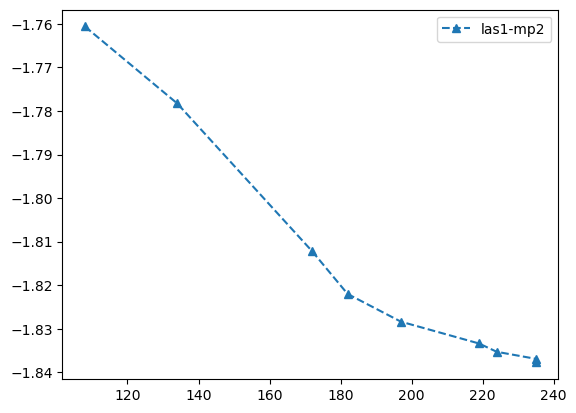

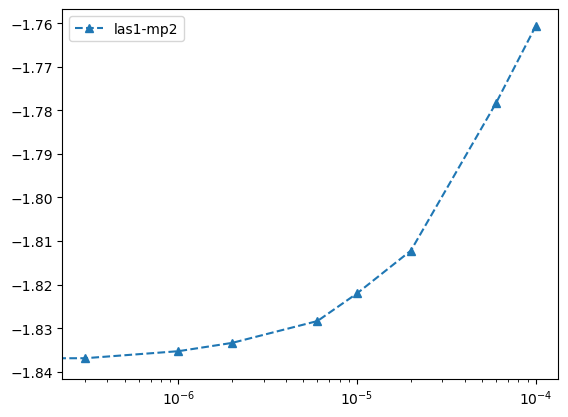

In [221]:
# reference

print(las1)
print(elnomp1)
from matplotlib import pyplot as plt
plt.plot(las1, elnomp1, "^--", color="C0", label="las1-mp2")
plt.legend()
plt.show()

import importlib, matplotlib.pyplot
importlib.reload(matplotlib.pyplot)

plt.plot(np.array(threshs), np.array(elnomp1), "^--", color="C0", label="las1-mp2")
plt.gca().set_xscale('log')
plt.legend()
plt.show()

In [213]:
lo_coeff = lo_coeff
frag_lolist = frag_lolist_2
nfrozen = elements.chemcore(mol)
run_frag_list = None # None - run all fragments, [0, 1, 2, 3, ...] run specific fragments
atom_group = atm_center

threshs = [1e-4, 6e-5, 2e-5, 1e-5, 6e-6, 2e-6, 1e-6, 3e-7, 0.0]
las2 = np.zeros(len(threshs))
elnomp2 = np.zeros(len(threshs))

for i, lno_thresh in enumerate(threshs):
    las2[i], elnomp2[i] = \
        run_oldlno(mf, lo_coeff, frag_lolist, nfrozen, lno_thresh, run_frag_list, atom_group)


 ******* LNO-CALCULATION ******* 

LO occ span the occupied MO occ space - True.
MO occ span the occupied LO occ space - False.
LNO THRESHOLD = [0.001, 0.0001]


===================== unrestricted LNO-FRAGMENT 1/(19,19) ======================
Center Atom Fe
LO occ proj: 9 active | 5 standby | 19 orthogonal
LO occ proj: 5 active | 9 standby | 15 orthogonal
nfrozen occupied orbitals:  [30, 26]
nactive occupied orbitals:  [14, 14]
nactive virtual orbitals:   [50, 48]
nfrozen virtual orbitals:   [152, 158]

WARN: CCSD detected DF being used in the HF object. MO integrals are computed based on the DF 3-index tensors.
It's recommended to use dfccsd.CCSD for the DF-CCSD calculations

Init t2, MP2 energy = -0.551956097367648
LNO-MP2 Orbital Energy:  -0.53295291


===================== unrestricted LNO-FRAGMENT 2/(19,19) ======================
Center Atom O
LO occ proj: 4 active | 1 standby | 28 orthogonal
LO occ proj: 4 active | 1 standby | 24 orthogonal
nfrozen occupied orbitals:  [39, 35]
n

In [217]:
emp2_ref = -1.83772509682127

[108. 134. 172. 182. 197. 219. 224. 235. 235.]
[-1.76061922 -1.77827667 -1.81219579 -1.82200553 -1.82835659 -1.83336615
 -1.83527373 -1.83688828 -1.8377251 ]
[ 64.  75. 114. 148. 155. 171. 184. 221. 235.]
[-1.76078514 -1.77150471 -1.80665712 -1.82093017 -1.82634891 -1.83324325
 -1.83491417 -1.83683461 -1.8377251 ]
-1.83772509682127


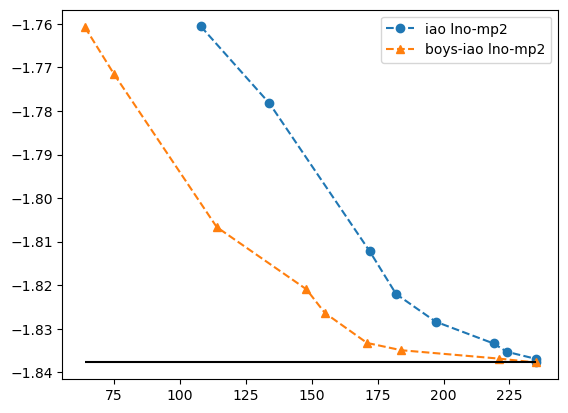

In [225]:
print(las1)
print(elnomp1)
print(las2)
print(elnomp2)
print(emp2_ref)
from matplotlib import pyplot as plt
plt.plot(las1, elnomp1, "o--", color="C0", label="iao lno-mp2")
plt.plot(las2, elnomp2, "^--", color="C1", label="boys-iao lno-mp2")
plt.hlines(emp2_ref, xmin=min(las2), xmax=max(las2), colors='k')
plt.legend()
plt.show()

In [234]:
lo_coeff = pmiao_coeff
frag_lolist = frag_lolist_3
nfrozen = elements.chemcore(mol)
run_frag_list = None # None - run all fragments, [0, 1, 2, 3, ...] run specific fragments
atom_group = atm_center

threshs = [1e-4, 6e-5, 2e-5, 1e-5, 6e-6, 2e-6, 1e-6, 3e-7, 0.0]
las3 = np.zeros(len(threshs))
elnomp3 = np.zeros(len(threshs))

for i, lno_thresh in enumerate(threshs):
    las3[i], elnomp3[i] = \
        run_oldlno(mf, lo_coeff, frag_lolist, nfrozen, lno_thresh, run_frag_list, atom_group)


 ******* LNO-CALCULATION ******* 

LO occ span the occupied MO occ space - True.
MO occ span the occupied LO occ space - False.
LNO THRESHOLD = [0.001, 0.0001]


===================== unrestricted LNO-FRAGMENT 1/(19,19) ======================
Center Atom Fe
LO occ proj: 9 active | 5 standby | 19 orthogonal
LO occ proj: 5 active | 9 standby | 15 orthogonal
nfrozen occupied orbitals:  [30, 26]
nactive occupied orbitals:  [14, 14]
nactive virtual orbitals:   [50, 48]
nfrozen virtual orbitals:   [152, 158]

WARN: CCSD detected DF being used in the HF object. MO integrals are computed based on the DF 3-index tensors.
It's recommended to use dfccsd.CCSD for the DF-CCSD calculations

Init t2, MP2 energy = -0.551956097367733
LNO-MP2 Orbital Energy:  -0.53295291


===================== unrestricted LNO-FRAGMENT 2/(19,19) ======================
Center Atom O
LO occ proj: 4 active | 1 standby | 28 orthogonal
LO occ proj: 4 active | 1 standby | 24 orthogonal
nfrozen occupied orbitals:  [39, 35]
n

[108. 134. 172. 182. 197. 219. 224. 235. 235.]
[-1.76061922 -1.77827667 -1.81219579 -1.82200553 -1.82835659 -1.83336615
 -1.83527373 -1.83688828 -1.8377251 ]
[ 64.  75. 114. 148. 155. 171. 184. 221. 235.]
[-1.76078514 -1.77150471 -1.80665712 -1.82093017 -1.82634891 -1.83324325
 -1.83491417 -1.83683461 -1.8377251 ]
[ 64.  75. 114. 148. 155. 171. 184. 221. 235.]
-1.83772509682127
[-1.76078514 -1.77150471 -1.80665712 -1.82093017 -1.82634891 -1.83324325
 -1.83491417 -1.83683461 -1.8377251 ]


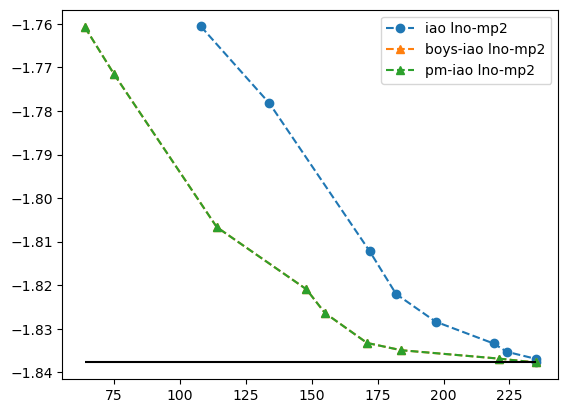

In [235]:
print(las1)
print(elnomp1)
print(las2)
print(elnomp2)
print(las3)
print(emp2_ref)
print(elnomp3)
from matplotlib import pyplot as plt
plt.plot(las1, elnomp1, "o--", color="C0", label="iao lno-mp2")
plt.plot(las2, elnomp2, "^--", color="C1", label="boys-iao lno-mp2")
plt.plot(las3, elnomp3, "^--", color="C2", label="pm-iao lno-mp2")
plt.hlines(emp2_ref, xmin=min(las2), xmax=max(las2), colors='k')
plt.legend()
plt.show()

In [160]:
lo_coeff = iao_coeff
frag_lolist = iao_frag_list
nfrozen = elements.chemcore(mol)
run_frag_list = [0] # None - run all fragments, [0, 1, 2, 3, ...] run specific fragments
atom_group = atm_center

# threshs = [1e-4, 6e-5, 2e-5, 1e-5, 6e-6]
las2 = np.zeros(len(threshs))
elnomp2 = np.zeros(len(threshs))
# elnocc2 = np.zeros(len(threshs))

for i, lno_thresh in enumerate(threshs):
    las2[i], elnomp2[i] = \
        run_newlno(mf, lo_coeff, frag_lolist, nfrozen, lno_thresh, run_frag_list, atom_group)


 ******* LNO-CALCULATION ******* 

LO occ span the occupied MO occ space - True.
MO occ span the occupied LO occ space - False.
LNO THRESHOLD = [0.00030000000000000003, 3e-05]


====================== unrestricted LNO-FRAGMENT 1/(1,19) ======================
Center Atom Fe
LO occ proj: 10 active | 5 standby | 18 orthogonal
LO occ proj: 6 active | 8 standby | 15 orthogonal
nfrozen occupied orbitals:  [11, 11]
nactive occupied orbitals:  [33, 29]
nactive virtual orbitals:   [127, 117]
nfrozen virtual orbitals:   [75, 89]
overlap rank = 146 of 146
intersection dim = 146 of 146
union rank = 146 of 146
intersection dim = 146
alpha active: occ 33/33, vir 113/127
beta  active: occ 29/29, vir 117/117

WARN: CCSD detected DF being used in the HF object. MO integrals are computed based on the DF 3-index tensors.
It's recommended to use dfccsd.CCSD for the DF-CCSD calculations

Init t2, MP2 energy = -1.64250966590676
LNO-MP2 Orbital Energy:  -0.54071653

 ******* LNO-CALCULATION ******* 

LO occ

In [151]:
print(las1)
print(elnomp1)

[160. 182. 219. 224.]
[-0.56916102 -0.57630479 -0.57744025 -0.57745723]


In [161]:
print(las2)
print(elnomp2)
# print(elnocc2)

[146. 180. 219. 224.]
[-0.54071653 -0.56926353 -0.57744025 -0.57745723]


In [162]:
print(elnomp2-elnomp1)
# print(elnocc2-elnocc1)

[2.84444966e-02 7.04126401e-03 8.88178420e-16 2.44249065e-15]


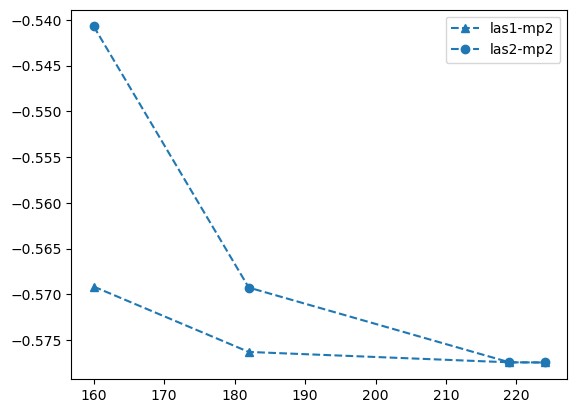

In [163]:
from matplotlib import pyplot as plt
plt.plot(las1, elnomp1, "^--", color="C0", label="las1-mp2")
# plt.plot(las1, elnocc1, "^--", color="C1", label="las1-cc")
plt.plot(las1, elnomp2, "o--", color="C0", label="las2-mp2")
# plt.plot(las1, elnocc2, "o--", color="C1", label="las2-cc")
plt.legend()
plt.show()

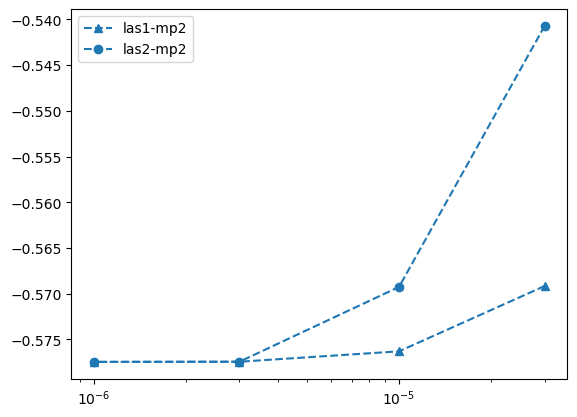

In [164]:
import importlib, matplotlib.pyplot
importlib.reload(matplotlib.pyplot)

plt.plot(np.array(threshs), np.array(elnomp1), "^--", color="C0", label="las1-mp2")
plt.plot(np.array(threshs), np.array(elnomp2), "o--", color="C0", label="las2-mp2")
plt.gca().set_xscale('log')
plt.legend()
plt.show()